In [74]:
from langgraph import graph
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv
The mypy_ipython extension is already loaded. To reload it, use:
  %reload_ext mypy_ipython


### Import Libraries

In [75]:
from langchain_core.runnables import Runnable
from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.graph import START,END, StateGraph
from typing_extensions import TypedDict
from collections.abc import Sequence
from langchain_core.messages import BaseMessage, HumanMessage

### Setup State

In [76]:
class State(TypedDict):
    message : Sequence[BaseMessage]

### Setup Node

In [77]:
chat = ChatOpenAI(model_name = 'gpt-4',
                  model_kwargs = {'seed':365},
                  temperature = 0,
                  max_tokens = 500)

/Users/sahilnagpal/Library/Python/3.9/lib/python/site-packages/IPython/core/interactiveshell.py:3490: UserWarning: Parameters {'seed'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


In [78]:
def chatbot(state: State) -> State:
    print(f"\n------> Entering the Chatbot : <-----\n")
    response = chat.invoke(state['message'])
    response.pretty_print()
    return State(message=[response])

In [79]:
def ask_question(state: State) -> State:
    print(f"\n------> Entering Ask Question : <-----\n")
    print("What is your question?")
    user_msg = HumanMessage(content=input())
    return {"message": [user_msg]}


In [80]:
ask_question(State(message =[]))


------> Entering Ask Question : <-----

What is your question?


{'message': [HumanMessage(content='Testing', additional_kwargs={}, response_metadata={})]}

In [81]:
def ask_another_question(state: State) -> State:
    print(f"\n------> Entering Ask Another Question : <-----\n")
    print("Do you have any other question? (yes/no)")
    return State(message = HumanMessage(content = input()))


In [82]:
ask_another_question(State(message=[]))


------> Entering Ask Another Question : <-----

Do you have any other question? (yes/no)


{'message': HumanMessage(content='Testing', additional_kwargs={}, response_metadata={})}

### Routing Function

In [83]:
def routing_function(state:State) -> Literal["ask_question","__end__"]:
    if state["message"].content == "yes":
        return "ask_question"
    else:
        return "__end__"

### Define The Graph

In [84]:
graph = StateGraph(State)

In [85]:
graph.add_node("ask_question",ask_question)
graph.add_node("chatbot",chatbot)
graph.add_node("ask_another_question",ask_another_question)


graph.add_edge(START,"ask_question")
graph.add_edge("ask_question","chatbot")
graph.add_edge("chatbot","ask_another_question")
graph.add_conditional_edges(source="ask_another_question",
                            path=routing_function,
                            path_map={"yes":"ask_question","no":"__end__"})

In [86]:
graph_compiled = graph.compile()

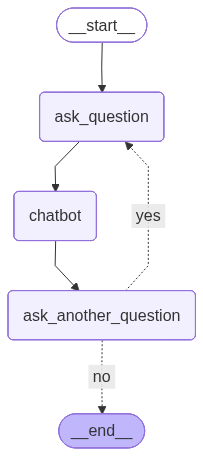

In [87]:
graph_compiled

In [88]:
graph_compiled.invoke(State(message=[]))


------> Entering Ask Question : <-----

What is your question?

------> Entering the Chatbot : <-----

================================== Ai Message ==================================

Hello! How can I assist you today?

------> Entering Ask Another Question : <-----

Do you have any other question? (yes/no)


KeyError: '__end__'